# Notebook 3 - The Watchlist 

This notebook turns the XGBoost out-of-fold probabilities into one of the project's  deliverables: a ranked watchlist of undesignated planning areas that most resemble Milieuschutz-designated ones. 

Working from the out-of-fold scores keeps every ranking honest, since each area was scored by a model that never saw its own district. After restricting to undesignated areas (y_true = 0), the distribution of scores is inspected to place a pragmatic cutoff, and the resulting shortlist is cross-checked against milieu_anteil, the continuous protected share, kept strictly out of the model as a feature and used here only to separate genuinely unprotected candidates from areas where some Milieuschutz already exists. 

The shortlist is then mapped across Berlin as an interpretive urgency layer (model similarity weighted by how little protection is already in place), and exported for the Cleanlab label-quality check in NB4 and for the dashboard. 

As throughout Module 2, the score expresses similarity to the existing designation pattern, not an objective probability of displacement. The undesignated areas surfacing near the top are precisely the early-warning candidates the platform is built to find.


In [1]:
#load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
#load the XGBoost OOF probabilities set 
xgb_oof = pd.read_csv("../../models/M_oof_xgboost.csv", dtype={"plr_id": str})

#load dataset_0 for readable identifiers (plr_name, bez)
meta = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
meta = meta[["plr_id", "plr_name", "bez"]]

#zero-pad plr_id consistently (same convention as NB1/NB2)
for d in (xgb_oof, meta):   
    d["plr_id"] = d["plr_id"].astype(str).str.zfill(8)

#build the working table: XGBoost oof_prob + labels + names/district
df = xgb_oof.merge(meta, on="plr_id", how="left")

#sanity 
assert df["plr_name"].notna().all(), "some PLR did not get a name/Bezirk — check the merge"
assert len(df) == len(xgb_oof), "merge changed row count — duplicate plr_id?"
print(f"{len(df)} PLR | {int(df['y_true'].sum())} designated | "
      f"{int((df['y_true']==0).sum())} undesignated")

527 PLR | 109 designated | 418 undesignated


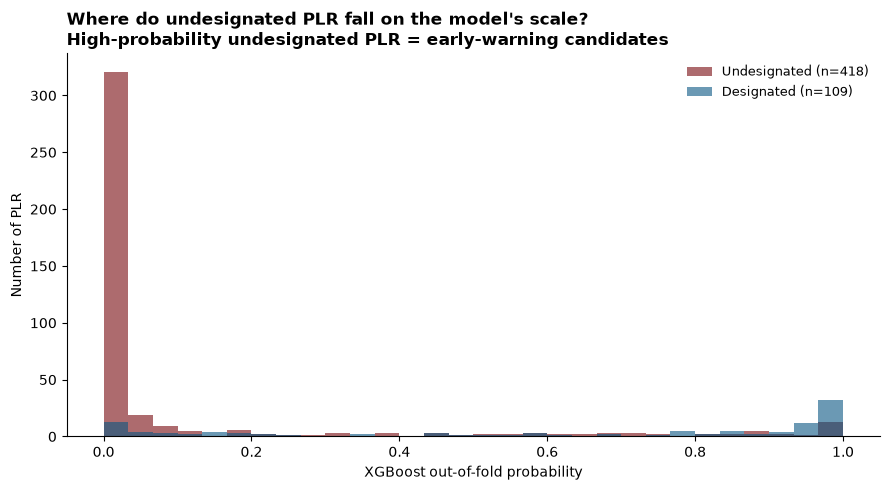

      plr_id                plr_name                              bez  oof_prob
0   01401044              Uferstraße                       01 - Mitte  0.999109
1   01300731           Koloniestraße                       01 - Mitte  0.997601
2   01100416             Arkonaplatz                       01 - Mitte  0.995976
3   07100206      Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
4   01200623             Stephankiez                       01 - Mitte  0.986148
5   01401049             Schulstraße                       01 - Mitte  0.985959
6   04501147       Leon-Jessel-Platz  04 - Charlottenburg-Wilmersdorf  0.984600
7   01300836   Humboldthain Nordwest                       01 - Mitte  0.984006
8   01200522      Elberfelder Straße                       01 - Mitte  0.983263
9   01200628       Lüneburger Straße                       01 - Mitte  0.979387
10  09200511       Griechischer Park            09 - Treptow-Köpenick  0.977478
11  01300834           Brunnenstraße    

In [3]:
#Distribution of XGBoost oof_prob, split by actual designation status
#Goal: where do undesignated PLR sit? Is there a natural cutoff for the watchlist that can be used?
desig   = df.loc[df["y_true"] == 1, "oof_prob"]
undesig = df.loc[df["y_true"] == 0, "oof_prob"]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 1, 31)
ax.hist(undesig, bins=bins, alpha=0.6, color="#77080D", label=f"Undesignated (n={len(undesig)})")
ax.hist(desig,   bins=bins, alpha=0.6, color="#095682", label=f"Designated (n={len(desig)})")
ax.set_xlabel("XGBoost out-of-fold probability", fontsize=10)
ax.set_ylabel("Number of PLR", fontsize=10)
ax.set_title("Where do undesignated PLR fall on the model's scale?\n"
             "High-probability undesignated PLR = early-warning candidates",
             fontsize=12, fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#eyeball the top undesignated PLR to see where probabilities start dropping
top_undesig = (df[df["y_true"] == 0]
               .sort_values("oof_prob", ascending=False)
               [["plr_id", "plr_name", "bez", "oof_prob"]]
               .head(30)
               .reset_index(drop=True))
print(top_undesig.to_string())

In [4]:
#Watchlist: undesignated PLR the model ranks most designation-like
#Cutoff N=25, chosen at the visible probability drop (~0.82 -> 0.77 after rank 24)

N_WATCHLIST = 25

watchlist = (
    df[df["y_true"] == 0]
    .sort_values("oof_prob", ascending=False)
    .head(N_WATCHLIST)
    .reset_index(drop=True)
    [["plr_id", "plr_name", "bez", "oof_prob"]]
)
watchlist.index = watchlist.index + 1          # 1-based rank for readability
watchlist.index.name = "rank"

#document the cutoff: what prob does the last included PLR have, and the first excluded?
cutoff_in  = watchlist["oof_prob"].iloc[-1]
first_out  = (df[df["y_true"] == 0]
              .sort_values("oof_prob", ascending=False)
              ["oof_prob"].iloc[N_WATCHLIST])
print(f"Watchlist: {N_WATCHLIST} undesignated PLR")
print(f"Cutoff: last included oof_prob = {cutoff_in:.3f} | first excluded = {first_out:.3f}")
print(f"Bezirk distribution:\n{watchlist['bez'].value_counts().to_string()}")
print()
print(watchlist.to_string())

Watchlist: 25 undesignated PLR
Cutoff: last included oof_prob = 0.824 | first excluded = 0.767
Bezirk distribution:
bez
01 - Mitte                         12
04 - Charlottenburg-Wilmersdorf     4
07 - Tempelhof-Schöneberg           3
09 - Treptow-Köpenick               2
02 - Friedrichshain-Kreuzberg       1
03 - Pankow                         1
08 - Neukölln                       1
12 - Reinickendorf                  1

        plr_id                plr_name                              bez  oof_prob
rank                                                                             
1     01401044              Uferstraße                       01 - Mitte  0.999109
2     01300731           Koloniestraße                       01 - Mitte  0.997601
3     01100416             Arkonaplatz                       01 - Mitte  0.995976
4     07100206      Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
5     01200623             Stephankiez                       01 - Mitte  0.986148
6

In [5]:
#milieu_anteil: interpretation only, never a feature. All 527 modelled PLR have a value
#variable has 0 NaNs, verified at target-variable build; anteil = 0 = observed "no protection"

labels_full = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})
labels_full["plr_id"] = labels_full["plr_id"].astype(str).str.zfill(8)

#pull milieu_anteil onto the watchlist
watchlist_checked = watchlist.merge(
    labels_full[["plr_id", "milieu_anteil"]], on="plr_id", how="left"
)
watchlist_checked.index = watchlist_checked.index + 1
watchlist_checked.index.name = "rank"

#classify: truly unprotected vs. partially protected (some Milieuschutz, but < 50%)
watchlist_checked["status"] = np.where(
    watchlist_checked["milieu_anteil"] > 0, "partially protected", "unprotected"
)

n_partial = (watchlist_checked["status"] == "partially protected").sum()
n_unprot  = (watchlist_checked["status"] == "unprotected").sum()
print(f"Of {len(watchlist_checked)} watchlist PLR: "
      f"{n_unprot} fully unprotected | {n_partial} partially protected (anteil > 0)\n")

print(watchlist_checked[["plr_name", "bez", "oof_prob", "milieu_anteil", "status"]].to_string())

Of 25 watchlist PLR: 4 fully unprotected | 21 partially protected (anteil > 0)

                    plr_name                              bez  oof_prob  milieu_anteil               status
rank                                                                                                       
1                 Uferstraße                       01 - Mitte  0.999109       0.487524  partially protected
2              Koloniestraße                       01 - Mitte  0.997601       0.221120  partially protected
3                Arkonaplatz                       01 - Mitte  0.995976       0.000959  partially protected
4         Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505       0.495631  partially protected
5                Stephankiez                       01 - Mitte  0.986148       0.383226  partially protected
6                Schulstraße                       01 - Mitte  0.985959       0.238271  partially protected
7          Leon-Jessel-Platz  04 - Charlottenburg-Wilmer

In [6]:
#Refine: milieu_anteil > 0 is too coarse. Split by how much protection already exists.
def classify(a):
    if a < 0.10:
        return "effectively unprotected"      # early-warning candidate
    elif a < 0.40:
        return "partially protected"          # protection started, substantial gap
    else:
        return "near-designated"              # just below the 50% majority threshold

watchlist_checked["status3"] = watchlist_checked["milieu_anteil"].apply(classify)
print(watchlist_checked["status3"].value_counts().to_string(), "\n")
print(watchlist_checked[["plr_name", "bez", "oof_prob", "milieu_anteil", "status3"]].to_string())

status3
partially protected        10
effectively unprotected    10
near-designated             5 

                    plr_name                              bez  oof_prob  milieu_anteil                  status3
rank                                                                                                           
1                 Uferstraße                       01 - Mitte  0.999109       0.487524          near-designated
2              Koloniestraße                       01 - Mitte  0.997601       0.221120      partially protected
3                Arkonaplatz                       01 - Mitte  0.995976       0.000959  effectively unprotected
4         Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505       0.495631          near-designated
5                Stephankiez                       01 - Mitte  0.986148       0.383226      partially protected
6                Schulstraße                       01 - Mitte  0.985959       0.238271      partially protected
7   

In [7]:
gdf = gpd.read_file("../../data/real_estate/Geodata/PLR_raw.geojson")
gdf["plr_id"] = gdf["plr_id"].astype(str).str.zfill(8)

print("Spalten:", gdf.columns.tolist())
print("CRS:", gdf.crs)
print("Zeilen:", len(gdf))
print(gdf.drop(columns="geometry").head(3).to_string())

Spalten: ['id', 'plr_id', 'plr_name', 'bzr_id', 'bzr_name', 'pgr_id', 'pgr_name', 'bez', 'finhalt', 'stadtraum_id', 'stadtraum_name', 'stand', 'geometry']
CRS: EPSG:25833
Zeilen: 542
                        id    plr_id           plr_name  bzr_id        bzr_name pgr_id pgr_name         bez       finhalt stadtraum_id stadtraum_name       stand
0  a_lor_plr_2021.01100101  01100101       Stülerstraße  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  3.669331e+05            1   Innere Stadt  01.01.2021
1  a_lor_plr_2021.01100102  01100102  Großer Tiergarten  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  3.919852e+06            1   Innere Stadt  01.12.2021
2  a_lor_plr_2021.01100103  01100103       Lützowstraße  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  5.471832e+05            1   Innere Stadt  01.12.2021


In [8]:
#Merge model output onto PLR geometries; milieu_anteil pulled in SEPARATELY (interpretation only, never a feature)

#labels_full holds milieu_anteil (from target_milieuschutz.csv) — kept out of df on purpose
plot_geo = (
    gdf
    .merge(df[["plr_id", "oof_prob", "y_true"]], on="plr_id", how="left")
    .merge(labels_full[["plr_id", "milieu_anteil"]], on="plr_id", how="left")
)

#urgency only for UNDESIGNATED PLR; designated + non-modelled stay NaN (grey)
undes = (plot_geo["y_true"] == 0)
plot_geo["urgency"] = np.nan
plot_geo.loc[undes, "urgency"] = (
    plot_geo.loc[undes, "oof_prob"] * (1 - plot_geo.loc[undes, "milieu_anteil"])
)

#diagnostics: how many geometries got no model row (the ~15 dropped PLR)?
n_nomatch = plot_geo["oof_prob"].isna().sum()
print(f"{len(plot_geo)} geometries | {n_nomatch} without a model row (dropped/uninhabited PLR)")
print(f"urgency range: {plot_geo['urgency'].min():.3f} – {plot_geo['urgency'].max():.3f}")

542 geometries | 15 without a model row (dropped/uninhabited PLR)
urgency range: 0.000 – 0.995


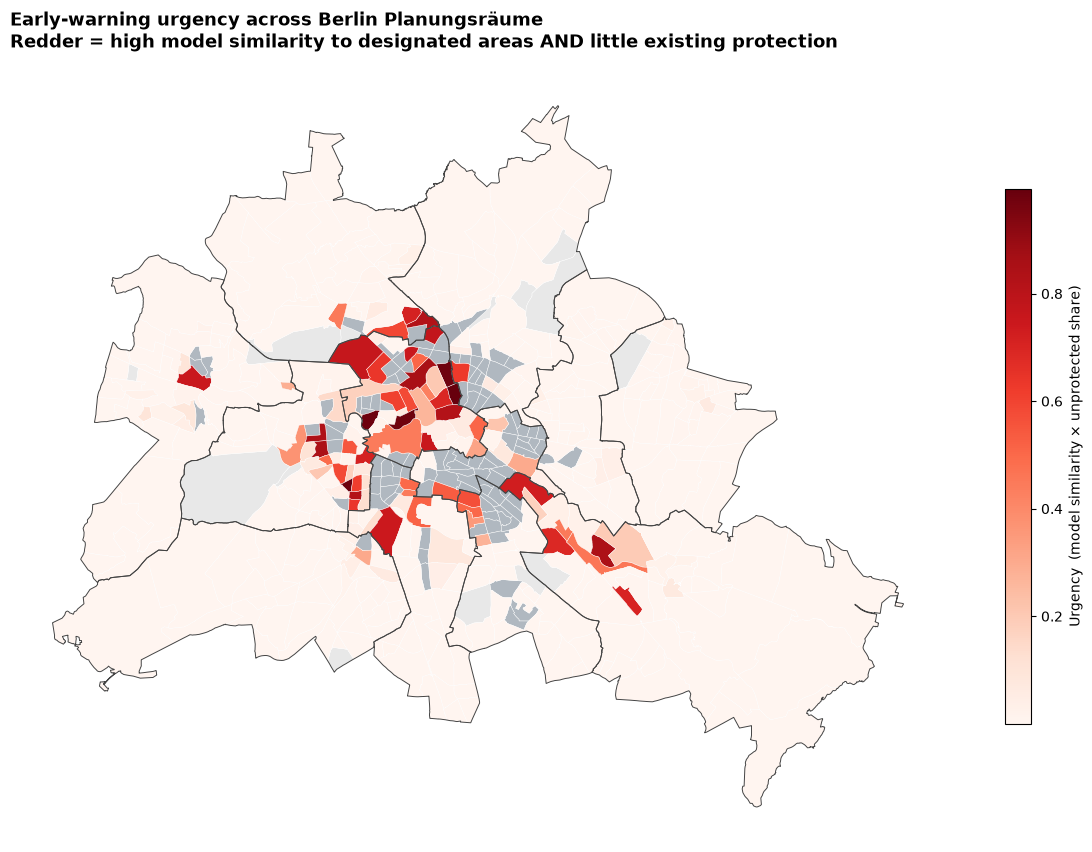

In [9]:
fig, ax = plt.subplots(figsize=(12, 11))

#layer 1: all PLR as light grey base (so dropped + designated areas are visible, not holes)
plot_geo.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)

#layer 2: designated PLR in a distinct neutral (already protected — not "urgent")
plot_geo[plot_geo["y_true"] == 1].plot(
    ax=ax, color="#b0b8c0", edgecolor="white", linewidth=0.3
)

#layer 3: undesignated PLR coloured by urgency (white -> red)
plot_geo[undes].plot(
    ax=ax, column="urgency", cmap="Reds", edgecolor="white", linewidth=0.3,
    legend=True, legend_kwds={"label": "Urgency  (model similarity × unprotected share)",
                              "shrink": 0.5}
)

#Bezirk outlines so the weak-fold districts are locatable
gdf.dissolve("bez").boundary.plot(ax=ax, color="#444444", linewidth=0.7)

ax.set_title("Early-warning urgency across Berlin Planungsräume\n"
             "Redder = high model similarity to designated areas AND little existing protection",
             fontsize=13, fontweight="bold", loc="left")
ax.axis("off")
plt.tight_layout()
plt.savefig("../../plots/watchlist_urgency_map.png", dpi=200, bbox_inches="tight")
plt.show()

### missing still:

PROBLEM: 
Die Watchlist rankt nach oof_prob, aber deine Karte färbt nach urgency — und die Tabelle zeigt schwarz auf weiß, wie stark die zwei auseinanderlaufen. Schau dir Rang 1 an: Uferstraße, oof_prob = 0.999 (Listen-Spitze!), aber milieu_anteil = 0.49. Die urgency ist also 0.999 × (1 − 0.49) ≈ 0.51 — nur mittelrot auf der Karte. Rang 4 (Großgörschenstraße, anteil 0.50) fällt sogar auf ~0.50 urgency. Dagegen Rang 3 (Arkonaplatz, anteil ≈ 0) bleibt bei ~0.996 urgency — dunkelrot. Der Listen-Erste ist auf der Karte blass, ein weiter unten Stehender leuchtet. Genau die Inkonsistenz, die du in Cell 10 als Teamdiskussion vermerkt hast — hier ist der konkrete Beleg.


Die roten Cluster liegen fast alle innerstädtisch, direkt neben den grauen (bereits geschützten) Flächen — Kreuzberg, Neukölln, Friedrichshain, der Streifen nach Südosten. 

Das ist inhaltlich genau, was die Frühwarn-These erwartet: Die Kandidaten sitzen im Ring um die schon geschützten Gebiete, nicht zufällig am Stadtrand. Das ist ein starkes Sanity-Signal, dass die Karte plausibel ist — dokumentier das ruhig in der Karten-Diskussion.

- NAs and already designated stärker auseinander 
- Grau legende 
- Liste und Karte basieren auf zwei verschiedenen Listen - muss geklärt werden. Teamdiskussion. 
- Und der Notebook-Satz zur konstruierten Größe ist hier besonders wichtig, weil die Karte so überzeugend aussieht, dass man urgency für einen Modell-Output halten könnte: „urgency is a derived interpretive score (model similarity × unprotected share), not a direct model prediction; grey = already designated or not modelled."


In [10]:
#Export the watchlist for NB4 Cleanlab validation + dashboard
watchlist_out = watchlist_checked[
    ["plr_id", "plr_name", "bez", "oof_prob", "milieu_anteil", "status3"]
].copy()

#add an explicit rank so the ordering survives the CSV round-trip
watchlist_out = watchlist_out.sort_values("oof_prob", ascending=False).reset_index(drop=True)
watchlist_out.insert(0, "rank", watchlist_out.index + 1)

watchlist_out.to_csv("../../models/M_watchlist.csv", index=False)
print(f"exported {len(watchlist_out)} watchlist PLR -> M_watchlist.csv")
print(watchlist_out.to_string(index=False))

exported 25 watchlist PLR -> M_watchlist.csv
 rank   plr_id               plr_name                             bez  oof_prob  milieu_anteil                 status3
    1 01401044             Uferstraße                      01 - Mitte  0.999109       0.487524         near-designated
    2 01300731          Koloniestraße                      01 - Mitte  0.997601       0.221120     partially protected
    3 01100416            Arkonaplatz                      01 - Mitte  0.995976       0.000959 effectively unprotected
    4 07100206     Großgörschenstraße       07 - Tempelhof-Schöneberg  0.992505       0.495631         near-designated
    5 01200623            Stephankiez                      01 - Mitte  0.986148       0.383226     partially protected
    6 01401049            Schulstraße                      01 - Mitte  0.985959       0.238271     partially protected
    7 04501147      Leon-Jessel-Platz 04 - Charlottenburg-Wilmersdorf  0.984600       0.000000 effectively unprotected
   